Group 17: Hetvi Chaniyara, Ece Kücük, Hande Pamuksuz

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [11]:
def generate_data(n):
    np.random.seed(10)
    xi = np.random.uniform(0,10,n)
    epsilon = np.random.normal(0,1, n)
    eta = 1.5*xi + 0.8 + epsilon
    return xi,eta

In [ ]:
n=50
xi, eta = generate_data(n)


In [ ]:
sum_xi = np.sum(xi)
sum_xi_sq = np.sum(xi**2)
sum_eta = np.sum(eta)
sum_xi_eta = np.sum(xi * eta)
sum_eta_sq = np.sum(eta**2)

H = 2 * np.array([[sum_xi_sq, sum_xi], 
                  [sum_xi, n]])

b = -2 * np.array([sum_xi_eta, sum_eta])

c = sum_eta_sq 

def objective_function(x):
    return 0.5 * x.T @ H @ x + b.T @ x + c

In [15]:
# Analytical Solution
x_analytic = np.linalg.solve(H, -b)
print(f"Analytic Solution (m, c): {x_analytic}")

Analytic Solution (m, c): [1.4715193  0.98453672]


In [16]:
minfunc = minimize(objective_function, x0=np.array([0, 0]))
print(f"Scipy Minimize Solution (m, c): {minfunc.x}")

Scipy Minimize Solution (m, c): [1.4715189  0.98453921]


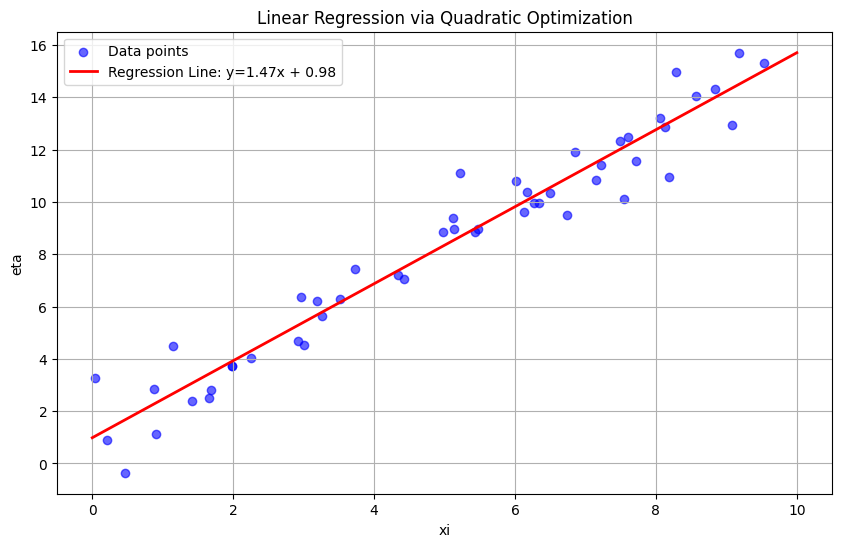

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(xi, eta, color='blue', label='Data points', alpha=0.6)

x_vals = np.linspace(0, 10, 100)
y_vals = minfunc.x[0] * x_vals + minfunc.x[1]
plt.plot(x_vals, y_vals, color='red', linewidth=2, label=f'Regression Line: y={minfunc.x[0]:.2f}x + {minfunc.x[1]:.2f}')

plt.xlabel('xi')
plt.ylabel('eta')
plt.title('Linear Regression via Quadratic Optimization')
plt.legend()
plt.grid(True)
plt.show()